# LLM10: Data Processing and Model Packaging

## Lab Overview

This lab covers the data processing pipeline for LLM training and the model packaging/loading mechanisms used in modern deep learning.

**Topics Covered:**

- Datasets and tokenizer fundamentals (encode, decode, padding, truncation, batch processing)
- Loading and preprocessing datasets with HuggingFace Datasets
- LLM packaging: `state_dict`, `safetensors`, `from_pretrained` / `save_pretrained`
- LoRA adapter loading via PEFT

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (e.g., AI Max+ 395, AI Max 390)

#### Software Environment

OS: Ubuntu 24.04.3 LTS \
Install [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html?family=ryzen-ai&gpu=…). After installing AUP Learning Cloud, you will have a ROCm and PyTorch environment that is compatible with this notebook.

## Goals

By the end of this lab, you will be able to:

1. **Understand Tokenization**: Master encode/decode, padding, truncation, and batch processing with HuggingFace tokenizers.
2. **Load and Explore Datasets**: Use HuggingFace Datasets to load, filter, and preprocess instruction-tuning data.
3. **Build Preprocessing Pipelines**: Convert raw text into tokenized, model-ready format using `map()`.
4. **Understand Model Internals**: Examine `nn.Module`, `nn.Linear`, `state_dict`, and parameter initialization.
5. **Master Model Packaging**: Save/load models with PyTorch and HuggingFace (`safetensors`, `from_pretrained`).
6. **Load LoRA Adapters**: Use PEFT to create and load LoRA adapters on a base model.

---


## 1. Environment Setup


In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import Dataset, load_dataset
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

plt.style.use("seaborn-v0_8")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
PyTorch version: 2.9.1+rocm7.2.0.git7e1940d4
GPU: AMD Radeon(TM) 8060S Graphics


Load librocdxg.so successully!
Load all DTIF APIs OK!


## 2. Tokenizer Fundamentals

The tokenizer converts human-readable text into token sequences that the model can process. It is the bridge between human language and LLM computation.

### Key Operations

| Operation                  | Description                                    | Example                    |
| -------------------------- | ---------------------------------------------- | -------------------------- |
| `tokenizer(text)`          | Returns `{'input_ids', 'attention_mask'}` dict | `tokenizer("Hello world")` |
| `tokenizer.tokenize(text)` | Returns subword tokens as strings              | `['Hello', ' world']`      |
| `tokenizer.encode(text)`   | Returns token ids (list of int)                | `[15496, 995]`             |
| `tokenizer.decode(ids)`    | Converts token ids back to text                | `'Hello world'`            |

### Batch Processing

When processing multiple texts, sequences have different lengths. Key parameters:

- **`padding`**: Pad shorter sequences to match the longest (`True`, `'max_length'`)
- **`truncation`**: Cut sequences exceeding max length (`True`)
- **`padding_side`**: Pad on `'left'` or `'right'`
- **`return_tensors`**: Return as PyTorch tensors (`'pt'`)


In [2]:
# Initialize tokenizer
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer: {model_name}")
print(f"Vocabulary size: {len(tokenizer)}")
print(f"Special tokens: {tokenizer.special_tokens_map}")
print(f"Pad token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")
print(f"EOS token: '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")

Tokenizer: gpt2
Vocabulary size: 50257
Special tokens: {'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}
Pad token: '<|endoftext|>' (id=50256)
EOS token: '<|endoftext|>' (id=50256)


In [3]:
# === Encode and Decode ===
text = "Tell me a story about Nanjing University."

# Method 1: tokenizer() returns dict with input_ids and attention_mask
encoded = tokenizer(text)
print("tokenizer(text):")
print(f"  input_ids:      {encoded['input_ids']}")
print(f"  attention_mask: {encoded['attention_mask']}")

# Method 2: tokenize() returns subword strings
tokens = tokenizer.tokenize(text)
print(f"\ntokenizer.tokenize(text): {tokens}")

# Method 3: encode() returns ids directly
ids = tokenizer.encode(text)
print(f"tokenizer.encode(text):   {ids}")

# Decode: convert ids back to text
decoded = tokenizer.decode(ids)
print(f"\ntokenizer.decode(ids): '{decoded}'")

tokenizer(text):
  input_ids:      [24446, 502, 257, 1621, 546, 18008, 49940, 2059, 13]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]

tokenizer.tokenize(text): ['Tell', 'Ġme', 'Ġa', 'Ġstory', 'Ġabout', 'ĠNan', 'jing', 'ĠUniversity', '.']
tokenizer.encode(text):   [24446, 502, 257, 1621, 546, 18008, 49940, 2059, 13]

tokenizer.decode(ids): 'Tell me a story about Nanjing University.'


In [4]:
# === Batch Processing with Padding ===
batch_sentences = [
    "Tell me a story about Nanjing University.",
    "What is deep learning?",
    "Large language models are transforming AI applications across many domains.",
]

# Without padding: sequences have different lengths
encoded_no_pad = tokenizer(batch_sentences)
print("Without padding:")
for i, ids in enumerate(encoded_no_pad["input_ids"]):
    print(f"  Sentence {i + 1}: {len(ids)} tokens")

# With padding=True: pad to longest in batch
encoded_padded = tokenizer(batch_sentences, padding=True, return_tensors="pt")
print("\nWith padding=True:")
print(f"  input_ids shape:      {encoded_padded['input_ids'].shape}")
print(f"  attention_mask shape: {encoded_padded['attention_mask'].shape}")
print(f"  attention_mask:\n{encoded_padded['attention_mask']}")

# With max_length + truncation: enforce fixed length
encoded_fixed = tokenizer(batch_sentences, padding="max_length", max_length=20, truncation=True, return_tensors="pt")
print("\nWith max_length=20:")
print(f"  input_ids shape: {encoded_fixed['input_ids'].shape}")

# Padding side: left vs right
tokenizer.padding_side = "left"
encoded_left = tokenizer(batch_sentences, padding=True, return_tensors="pt")
print(f"\nLeft padding attention_mask:\n{encoded_left['attention_mask']}")
tokenizer.padding_side = "right"  # Reset to default

Without padding:
  Sentence 1: 9 tokens
  Sentence 2: 5 tokens
  Sentence 3: 11 tokens

With padding=True:
  input_ids shape:      torch.Size([3, 11])
  attention_mask shape: torch.Size([3, 11])
  attention_mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

With max_length=20:
  input_ids shape: torch.Size([3, 20])

Left padding attention_mask:
tensor([[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


## 3. Dataset Loading and Exploration

HuggingFace Datasets provides a standard interface for loading and processing NLP datasets. The typical workflow:

1. **Load** dataset with `load_dataset()`
2. **Explore** structure and statistics
3. **Filter** low-quality samples
4. **Preprocess** with `dataset.map()`
5. **Split** into train/validation sets


In [5]:
# Load dataset
print("Loading Alpaca instruction-following dataset...")

try:
    dataset = load_dataset("yahma/alpaca-cleaned", split="train[:500]")
    print(f"Loaded {len(dataset)} samples")
except Exception as e:
    print(f"Error: {e}")
    # Fallback: create synthetic data
    synthetic = {
        "instruction": ["Explain quantum computing", "Write a sorting function"] * 250,
        "input": [""] * 500,
        "output": ["Quantum computing uses qubits...", "def sort(lst): return sorted(lst)"] * 250,
    }
    dataset = Dataset.from_dict(synthetic)
    print(f"Created synthetic dataset with {len(dataset)} samples")

# Explore structure
print(f"\nFeatures: {dataset.features}")
print(f"Columns:  {dataset.column_names}")

# Show sample
sample = dataset[0]
print("\nSample:")
for key, value in sample.items():
    display_val = f"{value[:80]}..." if len(str(value)) > 80 else value
    print(f"  {key}: {display_val}")

# Basic statistics
df = dataset.to_pandas()
for col in ["instruction", "input", "output"]:
    lengths = df[col].astype(str).str.len()
    empty = (df[col].astype(str).str.strip() == "").sum()
    print(f"\n{col}: mean_len={lengths.mean():.0f}, max={lengths.max()}, empty={empty}")

Loading Alpaca instruction-following dataset...
Loaded 500 samples

Features: {'output': Value('string'), 'input': Value('string'), 'instruction': Value('string')}
Columns:  ['output', 'input', 'instruction']

Sample:
  output: 1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a v...
  input: 
  instruction: Give three tips for staying healthy.

instruction: mean_len=81, max=2220, empty=0

input: mean_len=27, max=469, empty=290

output: mean_len=568, max=2616, empty=0


In [6]:
# Step 1: Filter low-quality samples
def keep_example(example):
    return len(example["output"].strip()) > 5


filtered = dataset.filter(keep_example)
print(f"After filtering: {len(filtered)} / {len(dataset)} samples kept")


# Step 2: Build structured messages
def build_messages(example):
    user_prompt = example["instruction"].strip()
    if example["input"]:
        user_prompt += "\n" + example["input"].strip()
    return {"text": f"### Instruction:\n{user_prompt}\n\n### Response:\n{example['output'].strip()}"}


structured = filtered.map(build_messages)
print(f"\nFormatted sample:\n{structured[0]['text'][:200]}...")

# Step 3: Train/validation split
split_data = structured.train_test_split(test_size=0.1, seed=42)
train_data = split_data["train"]
val_data = split_data["test"]
print(f"\nTrain: {len(train_data)}, Validation: {len(val_data)}")

After filtering: 498 / 500 samples kept

Formatted sample:
### Instruction:
Give three tips for staying healthy.

### Response:
1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whol...

Train: 448, Validation: 50


Tokenized train: 448 samples
Tokenized val:   50 samples
Sample keys: ['input_ids', 'attention_mask', 'labels']
Sample token count: 401

Token length stats: mean=156, median=117, max=512, 95th=397


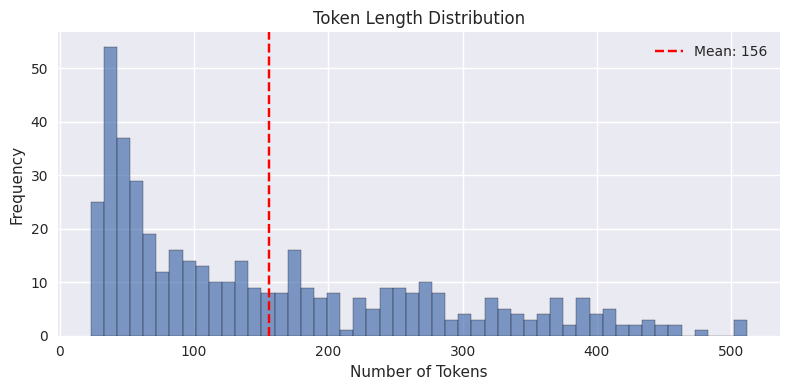

In [7]:
# Step 4: Tokenize with map()
def tokenize_function(examples):
    """Tokenize examples for causal language modeling."""
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        padding=False,  # We'll pad in batches later
    )
    # For causal LM: labels = input_ids (shifted internally by the model)
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized


tokenized_train = train_data.map(
    tokenize_function,
    batched=True,
    remove_columns=train_data.column_names,
)
tokenized_val = val_data.map(
    tokenize_function,
    batched=True,
    remove_columns=val_data.column_names,
)

print(f"Tokenized train: {len(tokenized_train)} samples")
print(f"Tokenized val:   {len(tokenized_val)} samples")
print(f"Sample keys: {list(tokenized_train[0].keys())}")
print(f"Sample token count: {len(tokenized_train[0]['input_ids'])}")

# Token length distribution
token_lengths = [len(x["input_ids"]) for x in tokenized_train]
print(
    f"\nToken length stats: mean={np.mean(token_lengths):.0f}, "
    f"median={np.median(token_lengths):.0f}, "
    f"max={np.max(token_lengths)}, "
    f"95th={np.percentile(token_lengths, 95):.0f}"
)

plt.figure(figsize=(8, 4))
plt.hist(token_lengths, bins=50, alpha=0.7, edgecolor="black")
plt.axvline(np.mean(token_lengths), color="red", linestyle="--", label=f"Mean: {np.mean(token_lengths):.0f}")
plt.title("Token Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Model Internals: nn.Module and nn.Linear

Before understanding model packaging, we need to understand the building blocks of PyTorch models.

### nn.Module

Every PyTorch model inherits from `nn.Module`. When you define layers in `__init__`, they are automatically registered and tracked.

### nn.Linear — The Core Building Block of LLMs

Many important parts of an LLM are built on `nn.Linear`, especially attention projections and feed-forward (MLP/FFN) layers.

Embedding layers are usually implemented with `nn.Embedding`, which is conceptually different from `nn.Linear` even though both involve learnable weight matrices.

```python
class Linear(Module):
    def __init__(self, in_features, out_features, bias=True):
        self.weight = Parameter(torch.empty((out_features, in_features)))
        self.bias = Parameter(torch.empty(out_features))  # if bias=True
        self.reset_parameters()   # initializes weight and bias with PyTorch's default Linear initialization

    def forward(self, input):
        return F.linear(input, self.weight, self.bias)
```

Key points:

- `Parameter()` wraps tensors and auto-registers them in `model.parameters()`
- Weight shape is `(out_features, in_features)` — transposed from the math convention
- Default initialization: `kaiming_uniform_` with `a=sqrt(5)`


In [8]:
# Examining nn.Linear internals
linear = nn.Linear(in_features=768, out_features=256, bias=True)
print(f"Linear layer: {linear}")
print(f"Weight shape: {linear.weight.shape}  (out_features x in_features)")
print(f"Bias shape:   {linear.bias.shape}")
print(f"Weight dtype:  {linear.weight.dtype}")
print(f"Weight stats:  mean={linear.weight.mean():.6f}, std={linear.weight.std():.6f}")
print(f"Total params:  {linear.weight.numel() + linear.bias.numel():,}")

# Forward pass
x = torch.randn(2, 768)  # batch_size=2, in_features=768
y = linear(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {y.shape}")

Linear layer: Linear(in_features=768, out_features=256, bias=True)
Weight shape: torch.Size([256, 768])  (out_features x in_features)
Bias shape:   torch.Size([256])
Weight dtype:  torch.float32
Weight stats:  mean=0.000048, std=0.020842
Total params:  196,864

Input shape:  torch.Size([2, 768])
Output shape: torch.Size([2, 256])


In [9]:
# Building a simple model to demonstrate model structure
class SimpleNetwork(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


model = SimpleNetwork()
print("Model structure:")
print(model)

# All parameters are auto-registered
print("\nRegistered parameters:")
for name, param in model.named_parameters():
    print(f"  {name}: shape={param.shape}, requires_grad={param.requires_grad}")

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Model structure:
SimpleNetwork(
  (fc1): Linear(in_features=768, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Registered parameters:
  fc1.weight: shape=torch.Size([256, 768]), requires_grad=True
  fc1.bias: shape=torch.Size([256]), requires_grad=True
  fc2.weight: shape=torch.Size([10, 256]), requires_grad=True
  fc2.bias: shape=torch.Size([10]), requires_grad=True

Total parameters: 199,434


## 5. Model Packaging: state_dict and Save/Load

PyTorch stores model parameters in `state_dict()` — an ordered dictionary mapping parameter names to tensors.

### Save and Load Flow

```
Save: model.state_dict() → torch.save() → disk (for example `.pt` or `.pth`)
Load: torch.load() → model.load_state_dict() → model ready
```

### Two Approaches

1. **Save parameters only** (recommended): `torch.save(model.state_dict(), 'weights.pt')`
2. **Save entire model** (includes code dependency): `torch.save(model, 'model.pt')`


In [10]:
# Examine state_dict
state = model.state_dict()
print("state_dict keys:")
print(list(state.keys()))

print("\nstate_dict contents:")
for key, tensor in state.items():
    print(f"  {key}: shape={tensor.shape}, dtype={tensor.dtype}")

# === Save and Load (parameters only) ===
import os
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    save_path = os.path.join(tmpdir, "model_weights.pt")

    # Save
    torch.save(model.state_dict(), save_path)
    file_size = os.path.getsize(save_path)
    print(f"\nSaved state_dict to {save_path}")
    print(f"File size: {file_size / 1024:.1f} KB")

    # Load into a new model instance
    model_new = SimpleNetwork()  # Must create model first
    model_new.load_state_dict(torch.load(save_path, weights_only=True))
    print("\nLoaded state_dict into new model")

    # Verify: parameters should be identical
    for (n1, p1), (n2, p2) in zip(model.named_parameters(), model_new.named_parameters()):
        assert torch.equal(p1, p2), f"Mismatch in {n1}"
    print("Verification passed: all parameters match!")

state_dict keys:
['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']

state_dict contents:
  fc1.weight: shape=torch.Size([256, 768]), dtype=torch.float32
  fc1.bias: shape=torch.Size([256]), dtype=torch.float32
  fc2.weight: shape=torch.Size([10, 256]), dtype=torch.float32
  fc2.bias: shape=torch.Size([10]), dtype=torch.float32

Saved state_dict to /tmp/tmpdpn0gt8k/model_weights.pt
File size: 781.5 KB

Loaded state_dict into new model
Verification passed: all parameters match!


## 6. HuggingFace Model Wrapping

HuggingFace provides a higher-level model packaging system built on top of PyTorch:

### safetensors

A safe, fast format for storing tensors (replaces pickle-based `.bin` files):

- **Safe**: No arbitrary code execution (unlike pickle)
- **Fast**: Efficient loading in modern model workflows
- **Standard**: Default format for HuggingFace models

### from_pretrained / save_pretrained

```python
# Load a pretrained model
model = AutoModelForCausalLM.from_pretrained(model_id)

# Save model (typically creates `config.json` plus a weight file such as `model.safetensors`)
model.save_pretrained(output_dir)
```

### What's Inside a HF Model Directory

Common files include:

```
model_dir/
├── config.json              # Model architecture config
├── model.safetensors        # Weights in safetensors format
├── tokenizer.json           # Tokenizer vocabulary
├── tokenizer_config.json    # Tokenizer settings
└── special_tokens_map.json  # Special token definitions
```


In [11]:
# Demonstrate safetensors save/load
try:
    from safetensors.torch import load_file, save_file

    with tempfile.TemporaryDirectory() as tmpdir:
        # Save using safetensors
        tensors = dict(model.state_dict().items())
        sf_path = os.path.join(tmpdir, "model.safetensors")
        save_file(tensors, sf_path)
        sf_size = os.path.getsize(sf_path)
        print(f"Saved in safetensors format: {sf_size / 1024:.1f} KB")

        # Load from safetensors
        loaded_tensors = load_file(sf_path)
        print(f"Loaded keys: {list(loaded_tensors.keys())}")

        # Verify
        for key in tensors:
            assert torch.equal(tensors[key], loaded_tensors[key])
        print("safetensors verification passed!")

except ImportError:
    print("safetensors not installed. Install with: pip install safetensors")

Saved in safetensors format: 779.3 KB
Loaded keys: ['fc1.bias', 'fc1.weight', 'fc2.bias', 'fc2.weight']
safetensors verification passed!


In [13]:
# HuggingFace from_pretrained / save_pretrained demo
print("Loading GPT-2 with from_pretrained...")

# Load model and tokenizer
hf_model = AutoModelForCausalLM.from_pretrained("gpt2")
hf_tokenizer = AutoTokenizer.from_pretrained("gpt2")

print(f"Model type: {type(hf_model).__name__}")
print(f"Model config: {hf_model.config.model_type}")
print(f"Parameters: {sum(p.numel() for p in hf_model.parameters()):,}")

# Examine the model structure
print("\nTop-level modules:")
for name, module in hf_model.named_children():
    param_count = sum(p.numel() for p in module.parameters())
    print(f"  {name}: {type(module).__name__} ({param_count:,} params)")

# Save and reload
with tempfile.TemporaryDirectory() as tmpdir:
    hf_model.save_pretrained(tmpdir)
    hf_tokenizer.save_pretrained(tmpdir)

    saved_files = os.listdir(tmpdir)
    print(f"\nSaved files: {saved_files}")
    for f in saved_files:
        size = os.path.getsize(os.path.join(tmpdir, f))
        print(f"  {f}: {size / 1024:.1f} KB")

    # Reload
    reloaded = AutoModelForCausalLM.from_pretrained(tmpdir)
    print(f"\nReloaded model parameters: {sum(p.numel() for p in reloaded.parameters()):,}")
    print("Save/load roundtrip successful!")

Loading GPT-2 with from_pretrained...


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model type: GPT2LMHeadModel
Model config: gpt2
Parameters: 124,439,808

Top-level modules:
  transformer: GPT2Model (124,439,808 params)
  lm_head: Linear (38,597,376 params)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved files: ['tokenizer_config.json', 'tokenizer.json', 'config.json', 'model.safetensors', 'generation_config.json']
  tokenizer_config.json: 0.3 KB
  tokenizer.json: 3474.3 KB
  config.json: 0.9 KB
  model.safetensors: 486107.6 KB
  generation_config.json: 0.1 KB


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Reloaded model parameters: 124,439,808
Save/load roundtrip successful!


## 7. PEFT LoRA Adapter Loading

LoRA (Low-Rank Adaptation) adapters are built **on top of** a base model. The PEFT library manages this:

1. **Load base model** with `from_pretrained`
2. **Create LoRA config** specifying rank, alpha, target modules
3. **Wrap model** with `get_peft_model()` — injects LoRA layers
4. **Train** only LoRA parameters (base model frozen)
5. **Save** only LoRA weights (tiny fraction of full model)

### LoRA Parameter Efficiency

For a Linear layer with shape `(d_out, d_in)` and LoRA rank `r`:

- Original parameters: `d_out × d_in`
- LoRA parameters: `d_out × r + r × d_in` (typically `r ≪ min(d_out, d_in)`)

```python
from peft import get_peft_model, LoraConfig, TaskType

peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,                    # LoRA rank
    lora_alpha=32,          # Scaling factor
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],  # Which layers to adapt
)
peft_model = get_peft_model(base_model, peft_config)
```

> Note: `target_modules` depends on the base model architecture.  
> For example, names like `q_proj` and `v_proj` are common in some transformer families, but GPT-2 uses different module names.


In [ ]:
# PEFT LoRA demonstration
try:
    from peft import LoraConfig, TaskType, get_peft_model

    # Base model (GPT-2 loaded earlier)
    # base_model = AutoModelForCausalLM.from_pretrained("gpt2")
    # We just loaded hf_model above, so we can reuse it instead of loading again
    base_model = hf_model
    base_params = sum(p.numel() for p in base_model.parameters())
    print(f"Base model parameters: {base_params:,}")

    # Create LoRA config
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        inference_mode=False,
        r=8,
        lora_alpha=32,
        lora_dropout=0.1,
    )

    # Wrap model with LoRA
    peft_model = get_peft_model(base_model, lora_config)

    # Parameter comparison
    trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in peft_model.parameters())
    print("\nAfter LoRA wrapping:")
    print(f"  Total parameters:     {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"  Trainable ratio:      {100 * trainable_params / total_params:.2f}%")

    # Show which modules were wrapped
    peft_model.print_trainable_parameters()

    # Save LoRA weights (much smaller than full model)
    with tempfile.TemporaryDirectory() as tmpdir:
        peft_model.save_pretrained(tmpdir)
        lora_files = os.listdir(tmpdir)
        print(f"\nSaved LoRA files: {lora_files}")
        total_size = sum(os.path.getsize(os.path.join(tmpdir, f)) for f in lora_files)
        print(f"Total LoRA size: {total_size / 1024:.1f} KB vs base model ~500 MB")

except ImportError:
    print("PEFT not installed.")
    print("Install with care: in some ROCm environments, `pip install peft` may modify the PyTorch installation.")
    print("Recommended: install PEFT only after confirming your PyTorch environment is stable.")

Base model parameters: 124,734,720

After LoRA wrapping:
  Total parameters:     124,734,720
  Trainable parameters: 294,912
  Trainable ratio:      0.24%
trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364


/home/lmy/llm/lib/python3.12/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/lmy/llm/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(



Saved LoRA files: ['adapter_model.safetensors', 'README.md', 'adapter_config.json']
Total LoRA size: 1161.0 KB vs base model ~500 MB


### PEFT / LoRA concepts

- `get_peft_model()` injects LoRA adapters into selected target modules of the base model
- Only LoRA parameters (~0.1–1% of total) are trainable
- `save_pretrained()` saves only LoRA weights (a few MB)
- Loading: load the base model first, then load the LoRA adapter on top


## Conclusions

### What We Covered (LLM10)

| Topic                     | Key Concepts                                                                       |
| ------------------------- | ---------------------------------------------------------------------------------- |
| **Tokenization**          | `encode`/`decode`, `padding`, `truncation`, `padding_side`, batch processing       |
| **Dataset Processing**    | `load_dataset`, `filter`, `map`, `train_test_split`, Alpaca format                 |
| **nn.Module / nn.Linear** | Parameter registration, module structure, `state_dict`, and default initialization |
| **Model Packaging**       | `torch.save`/`load`, `safetensors`, `from_pretrained`/`save_pretrained`            |
| **PEFT LoRA**             | `LoraConfig`, `get_peft_model`, adapter saving, parameter efficiency               |

### Connection to LLM11

In **LLM11**, we build on these foundations to implement:

- Collate functions for efficient batch processing
- Loss functions (autoregressive cross entropy, label masking)
- Complete training loops with AdamW, AMP, and gradient accumulation
- HuggingFace Trainer integration

### Experiment Further

- Try different tokenizers (LLaMA, Qwen) and compare vocabulary sizes and tokenization patterns
- Experiment with different LoRA ranks (r=4, 8, 16, 64) and observe the parameter efficiency tradeoff
- Load a real model with `from_pretrained` and examine its `state_dict` structure
- Compare `safetensors` file sizes with pickle-based `.bin` files


---

Copyright (C) 2025 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT
